# Notebook 3: Baseline OLS Regressions

For each of the four CEE markets I estimate a simple predictive regression:

$$r_{i,t+1} = \alpha_i + \beta_{1,i}\,\text{VIX}_t + \beta_{2,i}\,\Delta\text{VIX}_t + \varepsilon_{i,t+1}$$

A negative $\beta_2$ would mean that rising US fear today predicts falling CEE returns tomorrow, which is the main hypothesis of the paper (H1).

I stick with OLS rather than something more elaborate like GARCH-in-mean or quantile regression.

The one piece I do add is Newey-West HAC standard errors. Daily financial returns have heteroskedasticity (volatility clustering) and autocorrelation, both of which break the classical OLS assumptions about residuals. Newey-West corrects for both simultaneously, which gives me valid t-statistics under realistic conditions.

**Quarto - utilize for presentation**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.iolib.summary2 import summary_col
from pathlib import Path

Path("../figures").mkdir(exist_ok=True)

# load the regression-ready dataset
df = pd.read_parquet("../data/regression_data.parquet")

print(f"Observations: {len(df)}")
print(f"Date range:   {df.index[0].date()} to {df.index[-1].date()}")
print(f"\nColumns: {list(df.columns)}")
df.head()

Observations: 1635
Date range:   2018-01-04 to 2024-12-23

Columns: ['VIX_level', 'VIX_change', 'WIG20_next', 'BUX_next', 'PX_next', 'ATX_next']


,VIX_level,VIX_change,WIG20_next,BUX_next,PX_next,ATX_next
Date,,,,,,
2018-01-04,9.22,0.070001,-0.001430,0.003636,0.000172,0.000124
2018-01-05,9.22,0.000000,0.007507,0.002718,0.003252,-0.000183
2018-01-08,9.52,0.300000,-0.007969,-0.005864,-0.004012,0.002336
2018-01-09,10.08,0.559999,-0.006790,-0.005491,-0.002493,0.009308
2018-01-10,9.82,-0.260000,0.009231,0.003060,0.005386,0.002765


## Load the Regression Data

Everything I need is saved in `regression_data.parquet` from Notebook 1.

In [ ]:
def run_ols(y, X, lags=5):
    """
    Run OLS with Newey-West HAC standard errors.
    
    Parameters
    ----------
    y : pd.Series
        Dependent variable (next-day return).
    X : pd.DataFrame
        Independent variables. Constant will be added automatically.
    lags : int
        Number of lags for Newey-West correction. Default 5 (one trading week).
    
    Returns
    -------
    statsmodels regression results object
    """
    X_with_const = sm.add_constant(X)
    model = sm.OLS(y, X_with_const)
    # HAC = heteroskedasticity-and-autocorrelation-consistent (Newey-West)
    results = model.fit(cov_type="HAC", cov_kwds={"maxlags": lags})
    return results

# quick test on one market
test_y = df["WIG20_next"]
test_X = df[["VIX_level", "VIX_change"]]
test_results = run_ols(test_y, test_X)

print("Quick sanity check: WIG20 regression\n")
print(test_results.summary().tables[1])
print(f"\nR² = {test_results.rsquared:.4f}")
print(f"N  = {int(test_results.nobs)}")

## Define the OLS Function

A wrapper function makes the rest of the notebook cleaner. It takes the dependent variable (next-day return) and the independent variables (VIX level & change), adds a constant, and fits the model with Newey-West HAC standard errors using 5 lags.

The 5-lag choice corresponds to one trading week, which is the convention in the related literature when the residual autocorrelation structure is not defined but expected to die out within a few days. I should perform a verification in the diagnostics section below that this is sufficient.

Below, I run the wrapper on WIG20 first as a quick dataset sanity check before looping over all four markets.

In [6]:
# run OLS for each of the four CEE markets
markets = ["WIG20", "BUX", "PX", "ATX"]
results = {}

X = df[["VIX_level", "VIX_change"]]

for mkt in markets:
    y = df[f"{mkt}_next"]
    results[mkt] = run_ols(y, X)

# build a clean summary table comparing all four
summary = summary_col(
    list(results.values()),
    model_names=markets,
    stars=True,
    info_dict={
        "N"        : lambda x: f"{int(x.nobs)}",
        "R²"       : lambda x: f"{x.rsquared:.4f}",
        "Adj R²"   : lambda x: f"{x.rsquared_adj:.4f}",
    },
    regressor_order=["const", "VIX_level", "VIX_change"]
)

print("Table 4: OLS Predictive Regressions")
print("Dependent variable: next-day log return")
print("Newey-West HAC standard errors with 5 lags\n")
print(summary)

Table 4: OLS Predictive Regressions
Dependent variable: next-day log return
Newey-West HAC standard errors with 5 lags


                WIG20     BUX        PX      ATX   
---------------------------------------------------
const          -0.0005  0.0017   0.0016    0.0009  
               (0.0015) (0.0016) (0.0018)  (0.0025)
VIX_level      0.0000   -0.0001  -0.0001   -0.0000 
               (0.0001) (0.0001) (0.0001)  (0.0001)
VIX_change     -0.0008  -0.0008* -0.0007** -0.0008*
               (0.0005) (0.0004) (0.0003)  (0.0004)
R-squared      0.0127   0.0176   0.0250    0.0155  
R-squared Adj. 0.0115   0.0164   0.0238    0.0143  
Adj R²         0.0115   0.0164   0.0238    0.0143  
N              1635     1635     1635      1635    
R²             0.0127   0.0176   0.0250    0.0155  
Standard errors in parentheses.
* p<.1, ** p<.05, ***p<.01


## Run the Regression for All Four Markets

Now I loop over the four markets and stack the results into a single comparison table. `summary_col` from statsmodels produces a clean side-by-side view of the four regressions.

In [ ]:
# build a table
def format_coef(results, var_name):
    coef = results.params[var_name]
    se = results.bse[var_name]
    pval = results.pvalues[var_name]
    
    # stars
    stars = ""
    if pval < 0.01: stars = "***"
    elif pval < 0.05: stars = "**"
    elif pval < 0.10: stars = "*"
    
    return f"{coef:.5f}{stars}\n({se:.5f})"

paper_table = pd.DataFrame(index=[
    "Constant", "VIX level", "VIX change",
    "N", "R²", "Adjusted R²"
])

for mkt in markets:
    r = results[mkt]
    paper_table[mkt] = [
        format_coef(r, "const"),
        format_coef(r, "VIX_level"),
        format_coef(r, "VIX_change"),
        f"{int(r.nobs)}",
        f"{r.rsquared:.4f}",
        f"{r.rsquared_adj:.4f}",
    ]

print(paper_table.to_string())

paper_table.to_csv("../data/table_4_ols_results.csv")
print("\nNote: *, **, *** denote significance at 10%, 5%, and 1% levels.")
print("Standard errors in parentheses. Newey-West HAC with 5 lags.")

## Edit to Publication-Ready Version of the Table

The `summary_col` output is sufficient for inspection, however, I want the standard "coefficient on one line, standard error in parentheses below" format, as it's simpler to display within the paper. 

In [ ]:
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.stattools import jarque_bera

print("Regression Diagnostics\n")
print(f"{'Market':<8} {'Ljung-Box(5) p':>16} {'JB normality p':>16} {'Durbin-Watson':>15}")
print("-" * 60)

diagnostics = {}
for mkt in markets:
    r = results[mkt]
    resid = r.resid
    
    # Ljung-Box test for residual autocorrelation
    lb = acorr_ljungbox(resid, lags=[5], return_df=True)
    lb_pval = lb["lb_pvalue"].values[0]
    
    # Jarque-Bera test for normality of residuals
    jb_stat, jb_pval, _, _ = jarque_bera(resid)
    
    # Durbin-Watson statistic (should be ~2 if no autocorrelation)
    dw = sm.stats.stattools.durbin_watson(resid)
    
    diagnostics[mkt] = {"LB_p": lb_pval, "JB_p": jb_pval, "DW": dw}
    print(f"{mkt:<8} {lb_pval:>16.4f} {jb_pval:>16.4f} {dw:>15.3f}")

print("\nInterpretation:")

Regression Diagnostics

Market     Ljung-Box(5) p   JB normality p   Durbin-Watson
------------------------------------------------------------
WIG20              0.0421           0.0000           2.135
BUX                0.0026           0.0000           2.087
PX                 0.0004           0.0000           2.032
ATX                0.0000           0.0000           2.034

Interpretation:
  Ljung-Box p < 0.05  → residual autocorrelation present (Newey-West correction handles this)
  Jarque-Bera p < 0.05 → residuals not normally distributed (expected for financial data)
  Durbin-Watson ≈ 2    → no first-order autocorrelation


## Regression Diagnostics

Three quick tests on the residuals to make sure the Newey-West correction is appropriate.

**Ljung-Box** - residual autocorrelation at five lags. If the test rejects, there's autocorrelation that violates classical OLS assumptions, which is exactly the reason I'm using HAC standard errors in the first place. Rejection here is pretty much expected and confirms my choice of using HAC.

**Jarque-Bera** - normality of residuals. 

**Durbin-Watson** - first-order autocorrelation specifically. A value near 2 means no first-order autocorrelation. If the Ljung-Box rejects but DW is near 2, the autocorrelation is at higher lags (which Newey-West model would handle).

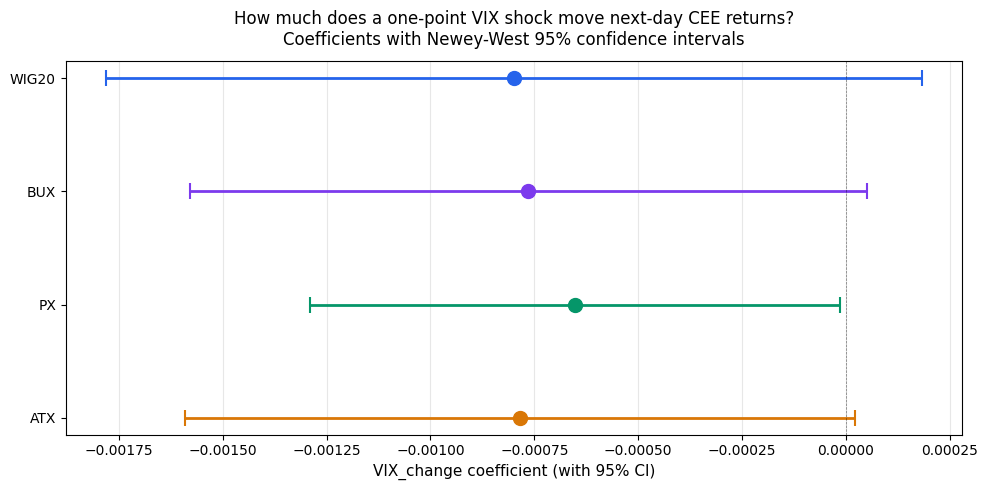

Saved → figures/04_coefficients.png


In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

# extract coefficients and 95% CIs for VIX_change across the four markets
coefs = []
ci_lower = []
ci_upper = []
for mkt in markets:
    r = results[mkt]
    coefs.append(r.params["VIX_change"])
    ci = r.conf_int(alpha=0.05).loc["VIX_change"]
    ci_lower.append(ci[0])
    ci_upper.append(ci[1])

colors_list = ["#2563eb", "#7c3aed", "#059669", "#d97706"]
x_positions = np.arange(len(markets))

# horizontal error bars showing 95% confidence intervals
for i, mkt in enumerate(markets):
    ax.errorbar(
        coefs[i], i,
        xerr=[[coefs[i] - ci_lower[i]], [ci_upper[i] - coefs[i]]],
        fmt="o",
        color=colors_list[i],
        capsize=6,
        capthick=1.5,
        markersize=10,
        linewidth=2,
        label=mkt
    )

# zero line
ax.axvline(0, color="black", linewidth=0.5, linestyle="--", alpha=0.5)

ax.set_yticks(x_positions)
ax.set_yticklabels(markets, fontsize=11)
ax.invert_yaxis()
ax.set_xlabel("VIX_change coefficient (with 95% CI)", fontsize=11)
ax.set_title("How much does a one-point VIX shock move next-day CEE returns?\n"
             "Coefficients with Newey-West 95% confidence intervals",
             fontsize=12, fontweight="500", pad=12)
ax.tick_params(labelsize=10)
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig("../figures/04_coefficients.png", dpi=150, bbox_inches="tight")
plt.show()